# Flight Delay Prediction — Exploratory Data Analysis

Data: BTS Reporting Carrier On-Time Performance, **Jan–Jun 2023**, restricted to flights between the
50 busiest US airports, joined with hourly airport weather from the Open-Meteo archive.

Target: `IS_DELAYED` = arrival delay ≥ 15 minutes (the DOT definition of a delayed flight).

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src import plot_style as ps
from src.config import PROCESSED_DIR, RAW_DIR, FIGURES_DIR, TARGET

ps.apply()
pd.set_option('display.max_columns', 40)

def save(fig, name):
    fig.savefig(FIGURES_DIR / f'{name}.png')

## 1. Load the cleaned data

In [2]:
df = pd.read_parquet(PROCESSED_DIR / 'flights_clean.parquet')
print(df.shape)
df.head()

(1977481, 23)


,flight_date,month,day_of_month,day_of_week,carrier,tail_number,flight_number,origin,dest,origin_state,dest_state,crs_dep_time,dep_delay,crs_arr_time,arr_delay,crs_elapsed_time,distance,distance_group,crs_dep_min,crs_arr_min,dep_hour,arr_hour,IS_DELAYED
0,2023-01-14,1,14,6,9E,N311PQ,4628,LGA,CVG,NY,KY,1500,-8.0,1720,-31.0,140.0,585.0,3,900,1040,15,17,0
1,2023-01-21,1,21,6,9E,N917XJ,4628,LGA,CVG,NY,KY,1500,-10.0,1720,-25.0,140.0,585.0,3,900,1040,15,17,0
2,2023-01-28,1,28,6,9E,N336PQ,4628,LGA,CVG,NY,KY,1500,-5.0,1720,-15.0,140.0,585.0,3,900,1040,15,17,0
3,2023-01-02,1,2,1,9E,N906XJ,4634,MSP,PIT,MN,PA,910,1.0,1220,-1.0,130.0,726.0,3,550,740,9,12,0
4,2023-01-04,1,4,3,9E,N138EV,4634,MSP,PIT,MN,PA,910,118.0,1220,246.0,130.0,726.0,3,550,740,9,12,1


In [3]:
df.dtypes

flight_date         datetime64[us]
month                        int64
day_of_month                 int64
day_of_week                  int64
carrier                        str
tail_number                    str
flight_number                int64
origin                         str
dest                           str
origin_state                   str
dest_state                     str
crs_dep_time                 int64
dep_delay                  float64
crs_arr_time                 int64
arr_delay                  float64
crs_elapsed_time           float64
distance                   float64
distance_group               int64
crs_dep_min                  int64
crs_arr_min                  int64
dep_hour                     int64
arr_hour                     int64
IS_DELAYED                    int8
dtype: object

In [4]:
df.isna().sum()[lambda s: s > 0]

Series([], dtype: int64)

In [5]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
flight_date,1977481,2023-04-02 09:20:21.129911,2023-01-01 00:00:00,2023-02-17 00:00:00,2023-04-03 00:00:00,2023-05-17 00:00:00,2023-06-30 00:00:00,NaN
month,1977481.0,3.553564,1.0,2.0,4.0,5.0,6.0,1.700994
day_of_month,1977481.0,15.635852,1.0,8.0,16.0,23.0,31.0,8.707892
day_of_week,1977481.0,3.946566,1.0,2.0,4.0,6.0,7.0,1.995835
flight_number,1977481.0,1904.894034,1.0,872.0,1675.0,2577.0,9887.0,1319.576704
crs_dep_time,1977481.0,1332.731186,1.0,900.0,1323.0,1753.0,2359.0,507.798551
dep_delay,1977481.0,14.333558,-59.0,-5.0,-1.0,12.0,3695.0,55.160668
crs_arr_time,1977481.0,1487.429332,1.0,1050.0,1520.0,1940.0,2400.0,545.495034
arr_delay,1977481.0,8.771512,-119.0,-14.0,-4.0,12.0,3680.0,57.454931
crs_elapsed_time,1977481.0,163.552399,1.0,106.0,149.0,197.0,697.0,76.42438


## 2. Target balance

Delayed: 23.3%   On-time: 76.7%   (1,977,481 flights)


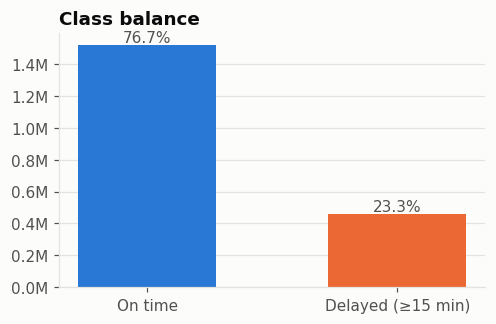

In [6]:
rate = df[TARGET].mean()
print(f'Delayed: {rate:.1%}   On-time: {1 - rate:.1%}   ({len(df):,} flights)')

fig, ax = plt.subplots(figsize=(5, 3))
counts = df[TARGET].value_counts().sort_index()
ax.bar(['On time', 'Delayed (≥15 min)'], counts.values, color=[ps.BLUE, ps.ORANGE], width=0.55)
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v / len(df):.1%}', ha='center', va='bottom', color=ps.TEXT_MUTED)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Class balance')
ax.grid(axis='x', visible=False)
save(fig, 'class_balance')

The classes are imbalanced (~23% delayed). Accuracy alone would be misleading — a model that always predicts
"on time" already scores ~77% — so ROC-AUC and F1 are tracked alongside accuracy during modelling.

## 3. Arrival delay distribution

count    1977481.0
mean           8.8
std           57.5
min         -119.0
50%           -4.0
75%           12.0
90%           47.0
95%           86.0
99%          211.0
max         3680.0
Name: arr_delay, dtype: float64


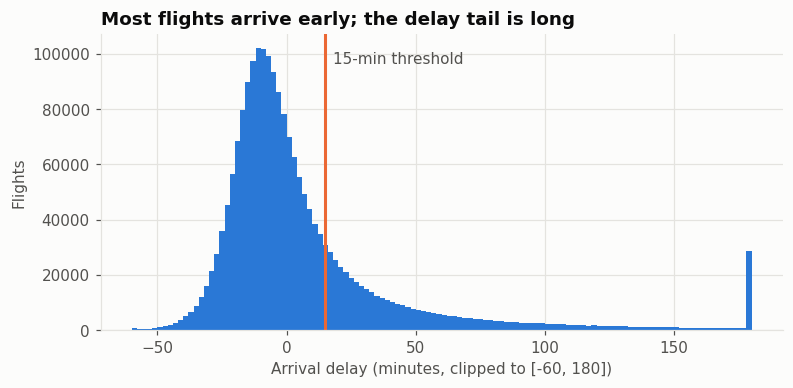

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(df['arr_delay'].clip(-60, 180), bins=120, color=ps.BLUE)
ax.axvline(15, color=ps.ORANGE, lw=2)
ax.text(18, ax.get_ylim()[1] * 0.9, '15-min threshold', color=ps.TEXT_MUTED)
ax.set_xlabel('Arrival delay (minutes, clipped to [-60, 180])')
ax.set_ylabel('Flights')
ax.set_title('Most flights arrive early; the delay tail is long')
save(fig, 'arrival_delay_hist')
print(df['arr_delay'].describe(percentiles=[.5, .75, .9, .95, .99]).round(1))

## 4. When do delays happen?

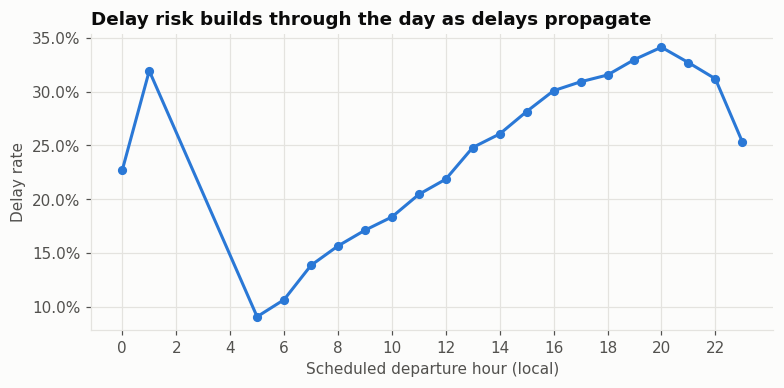

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.5))
by_hour = df.groupby('dep_hour')[TARGET].agg(['mean', 'size'])
by_hour = by_hour[by_hour['size'] > 500]
ax.plot(by_hour.index, by_hour['mean'], marker='o', ms=5, color=ps.BLUE)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel('Scheduled departure hour (local)')
ax.set_ylabel('Delay rate')
ax.set_title('Delay risk builds through the day as delays propagate')
save(fig, 'delay_by_hour')

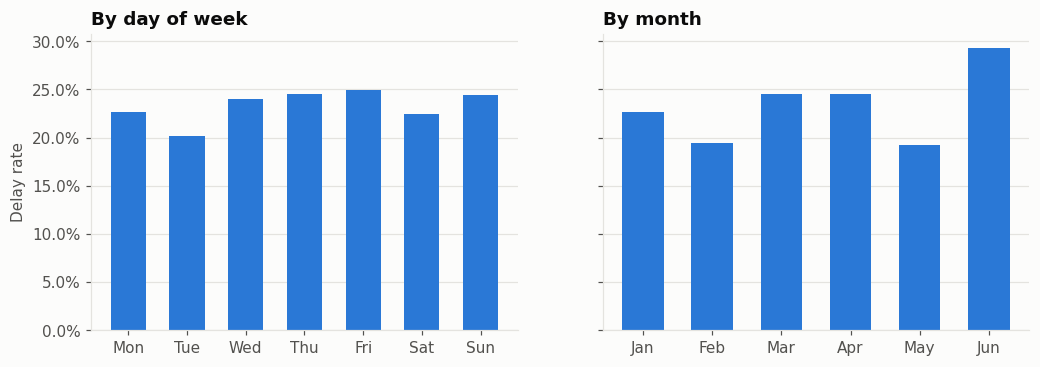

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
dow = df.groupby('day_of_week')[TARGET].mean()
axes[0].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], dow.values, color=ps.BLUE, width=0.6)
axes[0].set_title('By day of week')
mon = df.groupby('month')[TARGET].mean()
axes[1].bar(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'], mon.values, color=ps.BLUE, width=0.6)
axes[1].set_title('By month')
for ax in axes:
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Delay rate')
save(fig, 'delay_by_dow_month')

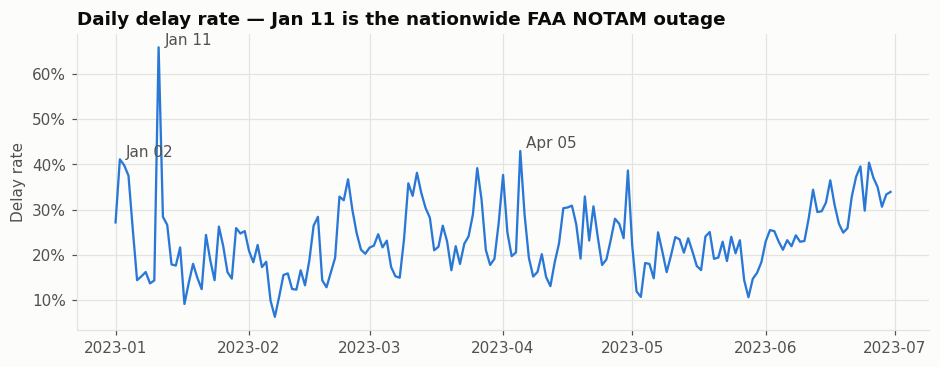

In [10]:
daily = df.groupby('flight_date')[TARGET].mean()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(daily.index, daily.values, color=ps.BLUE, lw=1.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
for d, v in daily.nlargest(3).items():
    ax.annotate(d.strftime('%b %d'), (d, v), xytext=(4, 2), textcoords='offset points', color=ps.TEXT_MUTED)
ax.set_title('Daily delay rate — Jan 11 is the nationwide FAA NOTAM outage')
ax.set_ylabel('Delay rate')
save(fig, 'daily_delay_rate')

## 5. Carriers, airports and routes

,mean,size
carrier,,
YX,0.133,91192
OH,0.158,15253
9E,0.160,27988
OO,0.175,69819
DL,0.196,338367
AS,0.223,75110
MQ,0.226,22611
UA,0.234,274076
WN,0.236,451317


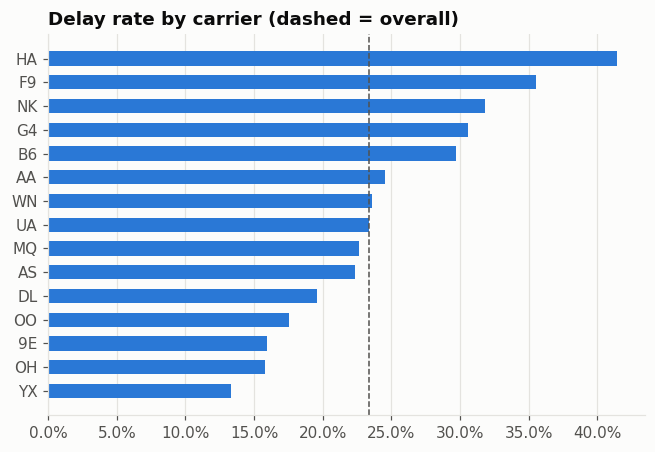

In [11]:
carrier = df.groupby('carrier')[TARGET].agg(['mean', 'size']).sort_values('mean')
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(carrier.index, carrier['mean'], color=ps.BLUE, height=0.6)
ax.axvline(df[TARGET].mean(), color=ps.TEXT_MUTED, lw=1, ls='--')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title('Delay rate by carrier (dashed = overall)')
ax.grid(axis='y', visible=False)
save(fig, 'delay_by_carrier')
carrier.round(3)

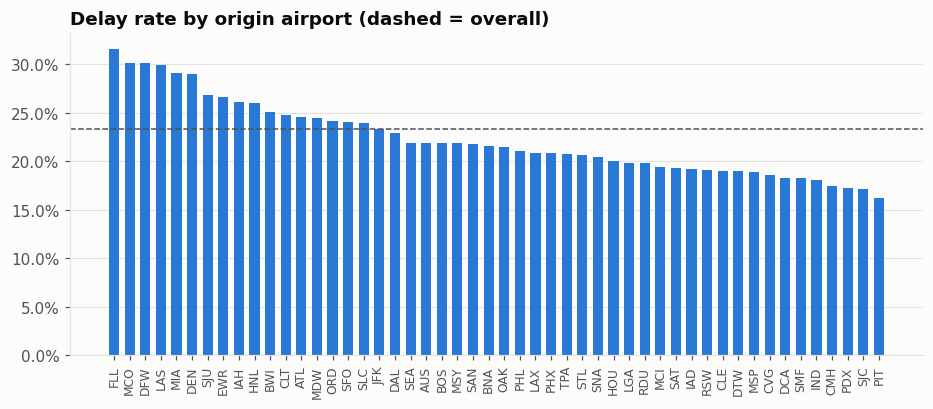

In [12]:
orig = df.groupby('origin')[TARGET].agg(['mean', 'size']).sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(orig.index, orig['mean'], color=ps.BLUE, width=0.65)
ax.axhline(df[TARGET].mean(), color=ps.TEXT_MUTED, lw=1, ls='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.grid(axis='x', visible=False)
ax.set_title('Delay rate by origin airport (dashed = overall)')
save(fig, 'delay_by_origin')

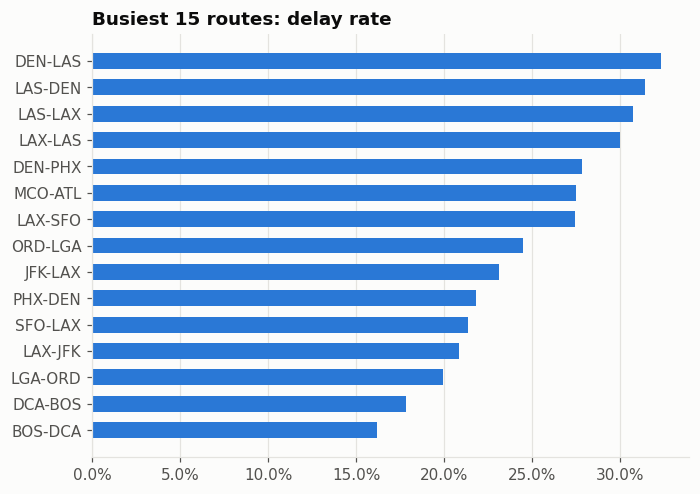

In [13]:
routes = (df.assign(route=df['origin'] + '-' + df['dest'])
            .groupby('route')[TARGET].agg(['mean', 'size'])
            .nlargest(15, 'size').sort_values('mean'))
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(routes.index, routes['mean'], color=ps.BLUE, height=0.6)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis='y', visible=False)
ax.set_title('Busiest 15 routes: delay rate')
save(fig, 'delay_by_route')

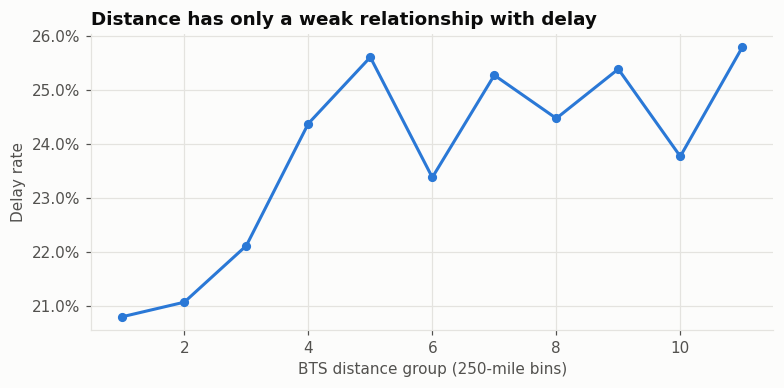

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.5))
dist = df.groupby('distance_group')[TARGET].agg(['mean', 'size'])
ax.plot(dist.index, dist['mean'], marker='o', ms=5, color=ps.BLUE)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_xlabel('BTS distance group (250-mile bins)')
ax.set_ylabel('Delay rate')
ax.set_title('Distance has only a weak relationship with delay')
save(fig, 'delay_by_distance')

## 6. Engineered features

The remaining sections use the feature table produced by `python -m src.build_features`
(time, route, aircraft-rotation, airport-state and weather features).

In [15]:
feat = pd.read_parquet(PROCESSED_DIR / 'features.parquet')
print(feat.shape)

(1977481, 82)


### 6.1 Weather

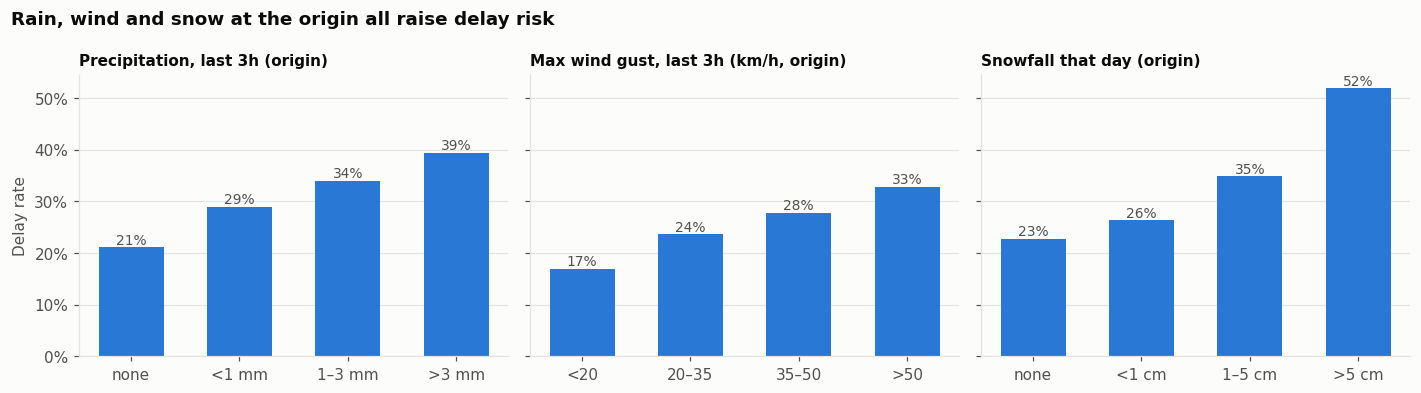

In [16]:
def rate_by_bucket(col, bins, labels):
    b = pd.cut(feat[col], bins=bins, labels=labels, include_lowest=True)
    return feat.groupby(b, observed=True)[TARGET].agg(['mean', 'size'])

panels = [
    ('origin_precip_3h', [0, 0.1, 1, 3, 100], ['none', '<1 mm', '1–3 mm', '>3 mm'], 'Precipitation, last 3h (origin)'),
    ('origin_gust_max_3h', [0, 20, 35, 50, 200], ['<20', '20–35', '35–50', '>50'], 'Max wind gust, last 3h (km/h, origin)'),
    ('origin_snow_day', [0, 0.01, 1, 5, 100], ['none', '<1 cm', '1–5 cm', '>5 cm'], 'Snowfall that day (origin)'),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, (col, bins, labels, title) in zip(axes, panels):
    r = rate_by_bucket(col, bins, labels)
    ax.bar(r.index.astype(str), r['mean'], color=ps.BLUE, width=0.6)
    for i, (m, n) in enumerate(zip(r['mean'], r['size'])):
        ax.text(i, m, f'{m:.0%}', ha='center', va='bottom', color=ps.TEXT_MUTED, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Delay rate')
fig.suptitle('Rain, wind and snow at the origin all raise delay risk', x=0.01, ha='left', fontweight='bold')
fig.tight_layout()
save(fig, 'delay_by_weather')

,mean,size
clear/cloudy,0.217,1664124
drizzle/fog,0.289,229407
rain,0.370,50543
heavy rain,0.524,3353
snow,0.456,28539
heavy snow,0.607,1515


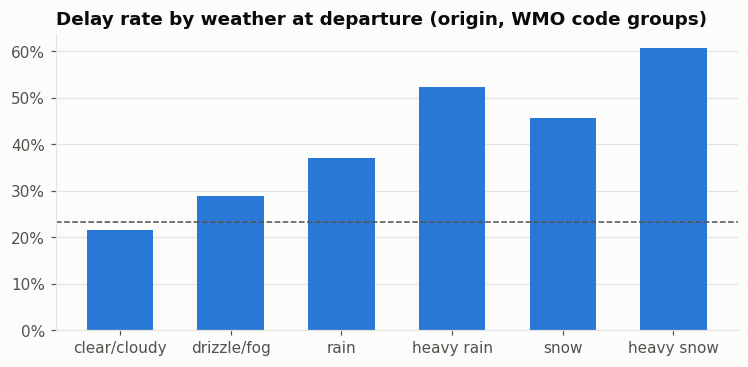

In [17]:
sev_labels = ['clear/cloudy', 'drizzle/fog', 'rain', 'heavy rain', 'snow', 'heavy snow', 'thunder']
sev = feat.groupby('origin_wx_severity')[TARGET].agg(['mean', 'size'])
sev.index = [sev_labels[i] for i in sev.index]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(sev.index, sev['mean'], color=ps.BLUE, width=0.6)
ax.axhline(feat[TARGET].mean(), color=ps.TEXT_MUTED, lw=1, ls='--')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis='x', visible=False)
ax.set_title('Delay rate by weather at departure (origin, WMO code groups)')
save(fig, 'delay_by_weather_severity')
sev.round(3)

### 6.2 Delay propagation through the aircraft rotation

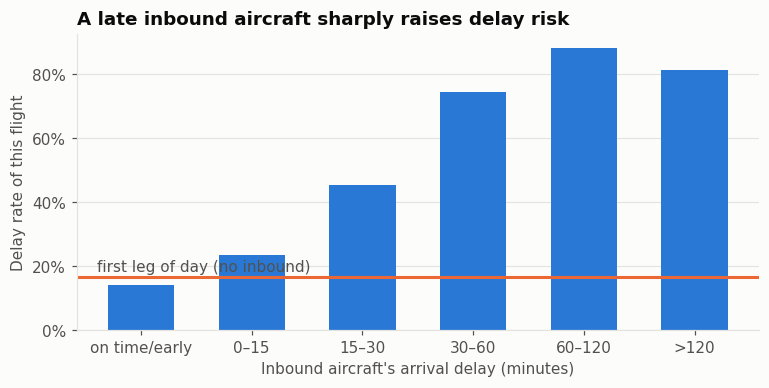

In [18]:
b = pd.cut(feat['prev_arr_delay'], [-200, 0, 15, 30, 60, 120, 5000],
           labels=['on time/early', '0–15', '15–30', '30–60', '60–120', '>120'])
first = feat['prev_leg_missing'] == 1
prop = feat[~first].groupby(b[~first], observed=True)[TARGET].mean()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(prop.index.astype(str), prop.values, color=ps.BLUE, width=0.6)
ax.axhline(feat.loc[first, TARGET].mean(), color=ps.ORANGE, lw=2)
ax.text(-0.4, feat.loc[first, TARGET].mean() + 0.01, 'first leg of day (no inbound)', color=ps.TEXT_MUTED, va='bottom')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis='x', visible=False)
ax.set_xlabel("Inbound aircraft's arrival delay (minutes)")
ax.set_ylabel('Delay rate of this flight')
ax.set_title('A late inbound aircraft sharply raises delay risk')
save(fig, 'delay_propagation')

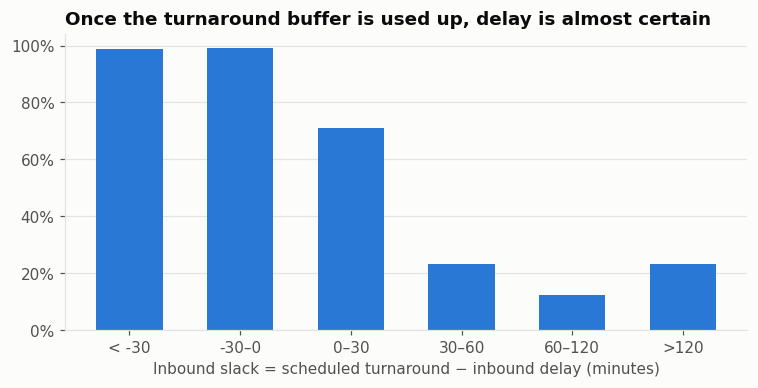

In [19]:
slack = pd.cut(feat['inbound_slack_min'], [-3000, -30, 0, 30, 60, 120, 3000],
               labels=['< -30', '-30–0', '0–30', '30–60', '60–120', '>120'])
s = feat[~first].groupby(slack[~first], observed=True)[TARGET].mean()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(s.index.astype(str), s.values, color=ps.BLUE, width=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis='x', visible=False)
ax.set_xlabel('Inbound slack = scheduled turnaround − inbound delay (minutes)')
ax.set_title('Once the turnaround buffer is used up, delay is almost certain')
save(fig, 'delay_by_inbound_slack')

### 6.3 Airport state

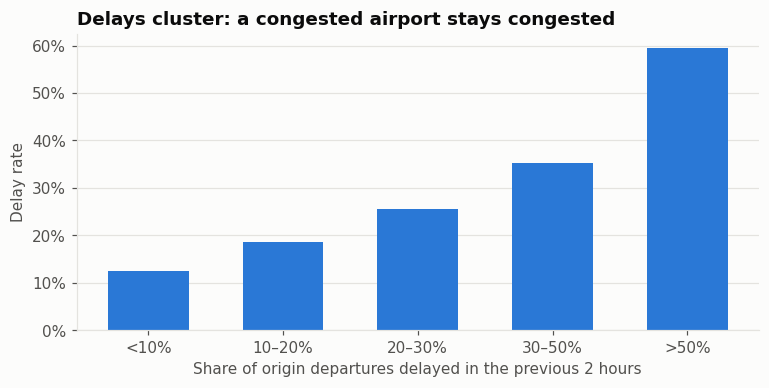

In [20]:
b = pd.cut(feat['origin_recent_delayed_share'], [-0.01, 0.1, 0.2, 0.3, 0.5, 1.0],
           labels=['<10%', '10–20%', '20–30%', '30–50%', '>50%'])
r = feat.groupby(b, observed=True)[TARGET].mean()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(r.index.astype(str), r.values, color=ps.BLUE, width=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.grid(axis='x', visible=False)
ax.set_xlabel('Share of origin departures delayed in the previous 2 hours')
ax.set_ylabel('Delay rate')
ax.set_title('Delays cluster: a congested airport stays congested')
save(fig, 'delay_by_airport_state')

### 6.4 Departure delay vs. arrival delay

The model predicts at pushback, so the flight's own departure delay is known. Flights can recover
time en route (schedule padding), so a late departure does not always mean a late arrival.

dep_delay
≤0       0.043
0–5      0.087
5–10     0.144
10–15    0.230
15–20    0.369
20–30    0.624
30–45    0.903
>45      0.996
Name: IS_DELAYED, dtype: float64

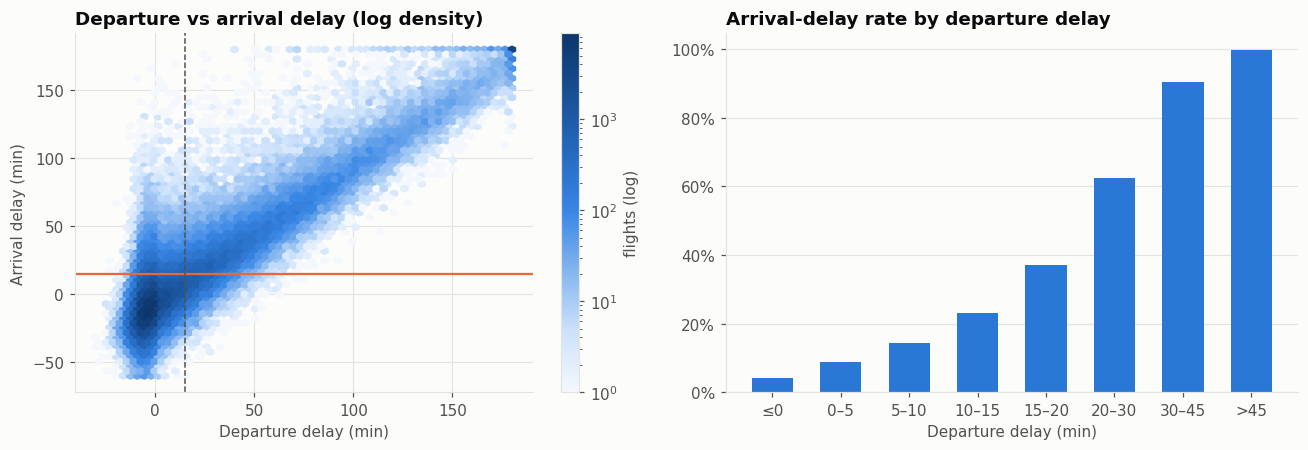

In [21]:
s = feat.sample(300_000, random_state=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
hb = axes[0].hexbin(s['dep_delay'].clip(-30, 180), s['arr_delay'].clip(-60, 180), gridsize=60,
                    bins='log', cmap=ps.SEQUENTIAL, mincnt=1)
axes[0].axhline(15, color=ps.ORANGE, lw=1.5)
axes[0].axvline(15, color=ps.TEXT_MUTED, lw=1, ls='--')
axes[0].set_xlabel('Departure delay (min)')
axes[0].set_ylabel('Arrival delay (min)')
axes[0].set_title('Departure vs arrival delay (log density)')
fig.colorbar(hb, ax=axes[0], label='flights (log)')

b = pd.cut(feat['dep_delay'], [-100, 0, 5, 10, 15, 20, 30, 45, 5000],
           labels=['≤0', '0–5', '5–10', '10–15', '15–20', '20–30', '30–45', '>45'])
r = feat.groupby(b, observed=True)[TARGET].mean()
axes[1].bar(r.index.astype(str), r.values, color=ps.BLUE, width=0.6)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].grid(axis='x', visible=False)
axes[1].set_xlabel('Departure delay (min)')
axes[1].set_title('Arrival-delay rate by departure delay')
fig.tight_layout()
save(fig, 'dep_vs_arr_delay')
r.round(3)

The 5–20 minute band is where the problem is genuinely uncertain: whether the flight makes up the time
depends on route padding, destination congestion and weather — exactly the features engineered above.

### 6.5 Correlation with the target

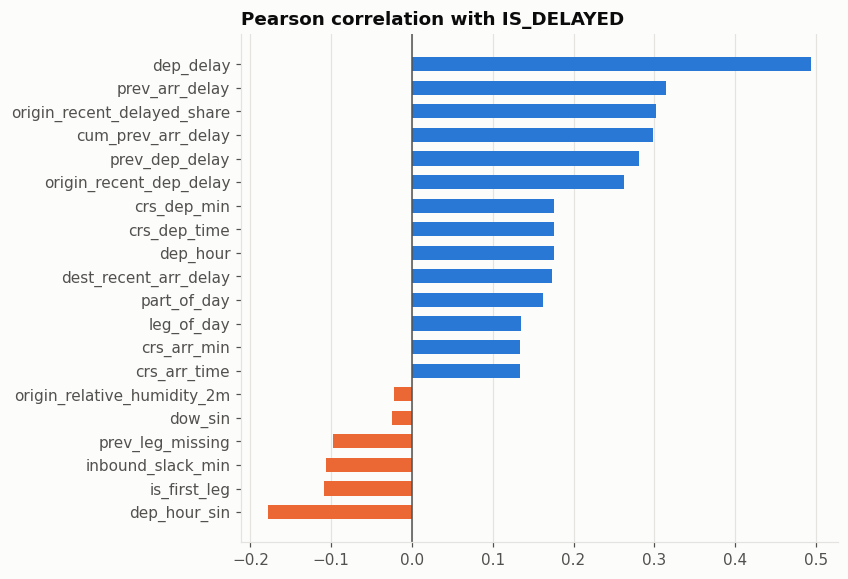

In [22]:
num = feat.select_dtypes('number').drop(columns=['arr_delay', 'flight_number', 'departed_late'])
corr = num.corr()[TARGET].drop(TARGET).sort_values()
top = pd.concat([corr.head(6), corr.tail(14)])
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color=[ps.ORANGE if v < 0 else ps.BLUE for v in top.values], height=0.6)
ax.axvline(0, color=ps.TEXT_MUTED, lw=1)
ax.grid(axis='y', visible=False)
ax.set_title('Pearson correlation with IS_DELAYED')
save(fig, 'feature_target_correlation')

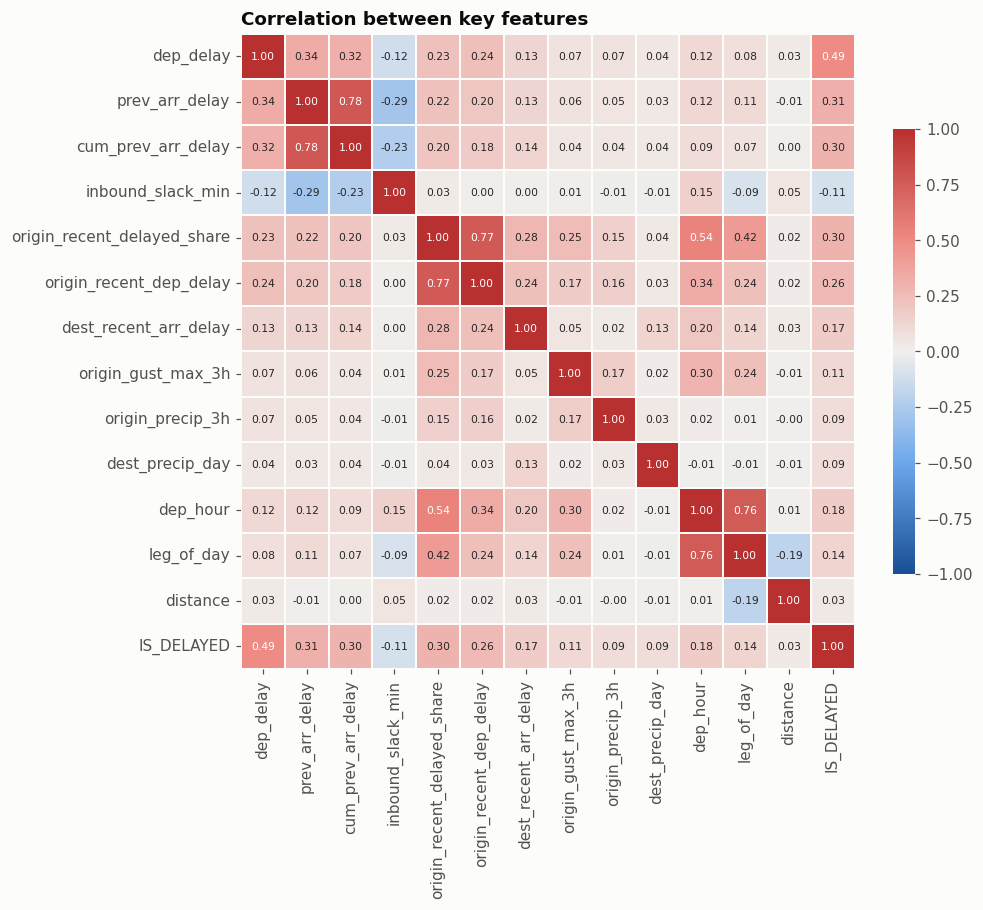

In [23]:
cols = ['dep_delay', 'prev_arr_delay', 'cum_prev_arr_delay', 'inbound_slack_min', 'origin_recent_delayed_share',
        'origin_recent_dep_delay', 'dest_recent_arr_delay', 'origin_gust_max_3h', 'origin_precip_3h',
        'dest_precip_day', 'dep_hour', 'leg_of_day', 'distance', TARGET]
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(feat[cols].corr(), cmap=ps.DIVERGING, vmin=-1, vmax=1, center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, linewidths=1, linecolor=ps.SURFACE, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Correlation between key features')
save(fig, 'feature_correlation_heatmap')

## 7. Takeaways for modelling

- **Departure delay is the anchor** at prediction time, but the 5–20 minute band is genuinely uncertain.
- **Propagated delay matters.** The inbound aircraft's delay, the remaining turnaround slack and the
  aircraft's cumulative delay that day are the strongest predictors.
- **Airport state matters.** Recent departure delays at the origin capture ground stops and congestion
  that per-flight features miss.
- **Weather adds signal on bad days.** Gusts, precipitation and snow raise delay rates sharply, though they
  only apply to a minority of flights.
- **Time of day** is a strong proxy for accumulated delay; carrier and airport identities add a baseline risk.
- The target is **imbalanced (~23% delayed)** and drifts month to month (June is worse), so the evaluation
  uses a time-based split and reports ROC-AUC and F1 alongside accuracy.